<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8009/blob/main/laboratorio_4_alum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCD8009: Data Discovery - Laboratorio 4

**Integrantes**

| N° | Código | Nombres |  Contribución (0% - 100%) |
|----|--------|---------|---------------------------|
| 1  |        |         |                           |
| 2  |        |         |                           |
| 3  |        |         |                           |
| 4  |        |         |                           |

### Indicaciones

- El laboratorio podrá resolverse de manera **individual o en equipos de hasta cuatro (4) personas**. Deberán completar los datos de todos los integrantes, y **una sola persona realizará la entrega del archivo ipynb**.

- Salvo que se indique explícitamente lo contrario, no se prohibe el uso de herramientas de Inteligencia Artificial Generativa, siempre que los integrantes comprendan y puedan explicar el proceso y los resultados obtenidos. **Las respuestas no deben consistir en transcripciones literales de resultados generados por estas herramientas, sino evidenciar comprensión del tema por parte del estudiante o del equipo.**

- En caso de utilizar herramientas de IA Generativa, cada equipo es responsable de verificar la coherencia de las respuestas presentadas. Si se detectan errores, inconsistencias o falta de comprensión, la pregunta podrá ser anulada sin derecho a reclamo.

- En todos los casos, deberá completarse la **Declaración de Uso de IA Generativa.**

- Pueden agregar libremente celdas de código o de Markdown según lo consideren conveniente.

### Declaración de uso de IA Generativa
- Indicar de manera breve la(s) herramienta(s) y/o modelo(s) de IA Generativa utilizados, especificando en qué pregunta(s) se emplearon y con qué propósito.
- En caso no se haya usado, también indicarlo.

## INICIO DEL LABORATORIO

### Parte 1: Feature engineering (5 puntos)

De la actividad grupal en clase de `Ideas de Feature engineering`, implemente 6 variables, de las cuales:
- Al menos una debe ser un encoding.
- Al menos una debe ser un escalado.
- Al menos una debe ser una discretización.
- Al menos una debe ser la creación de una nueva variable.

Además indique, para cada variable, qué técnica ha empleado.

Puede inspirarse de las propuestas de sus compañeros. (3 puntos)
- [Ideas de la sección 1](https://docs.google.com/presentation/d/1NctqdJAIoCf65jZgmKDR2ABQRB-JVE_BFyymi5K5Xss/edit?usp=sharing)
- [Ideas de la sección 2](https://docs.google.com/presentation/d/1uHzKY3laNwRZpQF5EC1UrcsbnBMnt6r1PeVImX-5gBE/edit?usp=sharing)

In [1]:
import pandas as pd
df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


#### Importar librerias

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

df_ames = df.copy()

#### Variable 1: Area Total Habitable

Superficie total construida y disponible para habitar, obtenida sumando `Total Bsmt SF` y `Gr Liv Area`

In [3]:
# Creación de Area Total Habitable
# Suma del área del sótano y el área sobre el suelo
df_ames['Total_SF'] = df_ames['Total Bsmt SF'] + df_ames['Gr Liv Area']

#### Variable 2: Antiguedad de la Propiedad

Determina la edad real al momento de la venta para estimar depreciación, obtenida de la diferencia entre `Yr Sold` y `Year Built`

In [4]:
# Creación de Antiguedad de la Propieda
# Año de venta menos año de construcción
df_ames['Antiguedad'] = df_ames['Yr Sold'] - df_ames['Year Built']

#### Variable 3: Tipo de Acceso

Aplicación de One-Hot Encoding a la variable `Street` para separar los tipos de acceso (Pave o Grvl)

In [5]:
# Encoding: Tipo de Acceso (Street)
# Aplicamos One-Hot Encoding para separar Pave y Grvl
df_ames = pd.get_dummies(df_ames, columns=['Street'], prefix='Street')

#### Variable 4: Calidad del Inmueble

Escalado Min-Max de la variable `Overall Qual` para normalizarla en un rango de 0 a 1 con la finalidad de facilitar las comparaciones.

In [6]:
# 4. Escalado: Calidad del Inmueble (Overall Qual)
# Normalización Min-Max para llevar el rango de 1-10 a 0-1 [1, 5]
scaler = MinMaxScaler()
df_ames['Overall_Qual_Scaled'] = scaler.fit_transform(df_ames[['Overall Qual']])

#### Variable 5: Segmentación por Número de Habitaciones

Categorización de `TotRms AbvGrd` en tres segmentos: "Pequeña", "Mediana" y "Grande"

In [9]:
# Visualizar estadisticas descriptivas de 'TotRms AbvGrd' para validar el rango numérico
# de la variable
df_ames['TotRms AbvGrd'].describe()

,TotRms AbvGrd
count,2930.000000
mean,6.443003
std,1.572964
min,2.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,15.000000


In [10]:
# Discretización: Segmentación por Número de Habitaciones
# Categorizamos 'TotRms AbvGrd' en Pequeña, Mediana y Grande
# Rango 2-15: 0-4 (Pequeña), 5-7 (Mediana), 8-15 (Grande)
df_ames['Rooms_Segment'] = pd.cut(df_ames['TotRms AbvGrd'],
                                  bins=[0, 4, 7, 15],
                                  labels=['Pequeña', 'Mediana', 'Grande'],
                                  right=True)

#### Variable 6: Baños Totales

Saber la cantidad de número de baños de la propiedad , se presume mientras mas baños tenga una casa el precio puede aumentar. Obtenida de la suma ponderada de baños completos y medio baños.

In [11]:
# Creación de Nueva Variable: Baños Totales
# Suma ponderada de baños completos y medios baños (sótano y niveles superiores) [10, 11]
df_ames['Total_Bathrooms'] = (df_ames['Full Bath'] + (0.5 * df_ames['Half Bath']) +
                              df_ames['Bsmt Full Bath'] + (0.5 * df_ames['Bsmt Half Bath']))



Ahora grafique algunos de sus nuevos features (ya sea mediante gráficos univariados o multivariados) e indique dos descubrimientos interesantes o conclusiones que le brindó esta nueva perspectiva. (2 puntos)

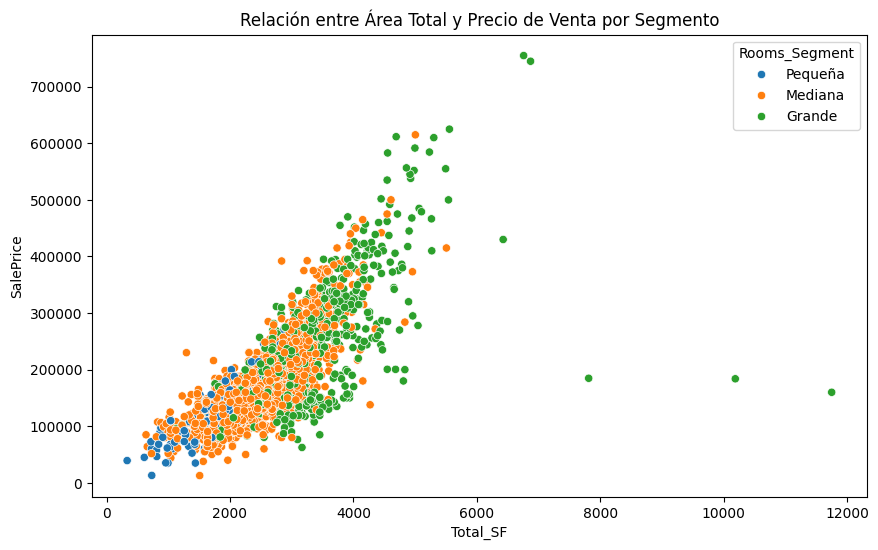

In [12]:
# Visualización de los resultados
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ames, x='Total_SF', y='SalePrice', hue='Rooms_Segment')
plt.title('Relación entre Área Total y Precio de Venta por Segmento')
plt.show()

A partir del gráfico de dispersión, se observa que:

* Existe una correlación lineal positiva muy fuerte entre el Total_SF y el SalePrice. Las casas con mayor metraje total tienden a concentrarse en precios superiores a los $200,000.
* La variable Antiguedad muestra que las propiedades más recientes (menos de 10 años) tienen una varianza de precio mucho mayor que las antiguas, lo que sugiere que otros factores (como acabados premium) influyen más en casas nuevas.

### Parte 2: Teoría (3 puntos) [Sin uso de herramientas de IA generativa]

Responda las siguientes preguntas (1pto cada uno):

a) ¿En qué medida la sobrecarga visual puede ser contraproducente en el descubrimiento de datos? ¿Cómo se pueden minimizar este problema?

b) ¿Qué riesgos existen al basar decisiones en patrones identificados a través de Visual Data Discovery, considerando que las visualización NO son neutrales?

c) ¿Cómo se pueden mitigar los efectos de la manipulación visual en la toma de decisiones basada en datos?

### Parte 3: Trabajo integrador (12 puntos)

Este ejercicio consiste en aplicar **Visual Data Discovery** para identificar patrones en un dataset. En particular, trabajaremos con un dataset sobre **pérdidas de clientes en Telco**, una empresa del sector telecomunicaciones. El objetivo es **identificar factores de riesgo de abandono (churn)**, lo que permitirá desarrollar estrategias de **retención de clientes** y respaldar **decisiones informadas en un contexto de negocio**.  

El entregable es el notebook que presente:
- El desarrollo (proceso) del EDA (formato libre).
- Una sección ejecutiva que incluya:
    - 4 o 5 visualizaciones clave, indicando la historia que cuenta cada gráfico en relación con la problemática.
    - Al menos 3 recomendaciones estratégicas enfocándose en insights accionables, los cuales sean respaldados por las visualizaciones realizadas anteriormente.

#### **Objetivos del Análisis**  
1. Detectar patrones y segmentos de clientes con alto riesgo de churn.
2. Identificar factores críticos que contribuyen a la pérdida de clientes.
3. Proponer estrategias basadas en los hallazgos para reducir la tasa de abandono.
4. Presentar los resultados de manera clara y accionable para la toma de decisiones.
   
#### **Consideraciones para las visualizaciones**  
- Preparar visualizaciones que resalten los hallazgos clave.
- Utilizar gráficos claros y concisos, asegurándose de que respalden las recomendaciones para la toma de decisiones.  
- Aplicar buenas prácticas en visualización de datos.

#### **Consideraciones para las recomendaciones estratégicas**  
- Con base en los resultados obtenidos, desarrollar estrategias de retención específicas.  
- Justificar cómo estas recomendaciones podrían reducir el churn y el impacto que tendrían en el negocio.  

#### **Nota:**
- La calificación tomará en cuenta el orden y presentación del cuadernillo, la claridad y diseño de los gráficos, y la calidad de las recomendaciones.

In [1]:
import pandas as pd

demographics = pd.read_csv("Telco_customer_churn_demographics.csv")
location = pd.read_csv("Telco_customer_churn_location.csv")
population = pd.read_csv("Telco_customer_churn_population.csv")
status = pd.read_csv("Telco_customer_churn_status.csv")
services = pd.read_csv("Telco_customer_churn_services.csv")

### 3.1 Análisis Exploratorio de Datos (EDA)

Mostrar Información de dataset "demographics"

In [11]:
print('#'*10 + ' Cabecera de dataset "demographics" ' + '#'*10)
display(demographics.head())
print('#'*10 + ' Información de dataset "demographics" ' + '#'*10)
display(demographics.info())
print('#'*10 + ' Descripción de dataset "demographics" ' + '#'*10)
display(demographics.describe())

########## Cabecera de dataset "demographics" ##########


,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,1,M,78,No,Yes,No,No,0
1,7495-OOKFY,1,F,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,1,M,71,No,Yes,No,Yes,3
3,4598-XLKNJ,1,F,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,1,F,80,No,Yes,Yes,Yes,1


##########Información de dataset "demographics"##########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Customer ID           7043 non-null   object
 1   Count                 7043 non-null   int64 
 2   Gender                7043 non-null   object
 3   Age                   7043 non-null   int64 
 4   Under 30              7043 non-null   object
 5   Senior Citizen        7043 non-null   object
 6   Married               7043 non-null   object
 7   Dependents            7043 non-null   object
 8   Number of Dependents  7043 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 495.3+ KB


None

##########Descripción de dataset "demographics"##########


,Count,Age,Number of Dependents
count,7043.0,7043.000000,7043.000000
mean,1.0,47.466279,0.468692
std,0.0,18.391529,0.962802
min,1.0,19.000000,0.000000
25%,1.0,33.000000,0.000000
50%,1.0,46.000000,0.000000
75%,1.0,60.000000,0.000000
max,1.0,119.000000,9.000000


Mostrar Información de dataset "location"

In [12]:
print('#'*10 + ' Cabecera de dataset "location" ' + '#'*10)
display(location.head())
print('#'*10 + ' Información de dataset "location" ' + '#'*10)
display(location.info())
print('#'*10 + ' Descripción de dataset "location" ' + '#'*10)
display(location.describe())

##########Cabecera de dataset "location"##########


,Customer ID,Count,Country,State,City,Zip Code,Latitude,Longitude
0,8779-QRDMV,1,United States,California,Los Angeles,90022,34.023810,-118.156582
1,7495-OOKFY,1,United States,California,Los Angeles,90063,34.044271,-118.185237
2,1658-BYGOY,1,United States,California,Los Angeles,90065,34.108833,-118.229715
3,4598-XLKNJ,1,United States,California,Inglewood,90303,33.936291,-118.332639
4,4846-WHAFZ,1,United States,California,Whittier,90602,33.972119,-118.020188


##########Información de dataset "location"##########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  7043 non-null   object 
 1   Count        7043 non-null   int64  
 2   Country      7043 non-null   object 
 3   State        7043 non-null   object 
 4   City         7043 non-null   object 
 5   Zip Code     7043 non-null   int64  
 6   Latitude     7043 non-null   float64
 7   Longitude    7043 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 440.3+ KB


None

##########Descripción de dataset "location"##########


,Count,Zip Code,Latitude,Longitude
count,7043.0,7043.000000,7043.000000,7043.000000
mean,1.0,93486.070567,36.197455,-119.756684
std,0.0,1856.767505,2.468929,2.154425
min,1.0,90001.000000,32.555828,-124.301372
25%,1.0,92101.000000,33.990646,-121.788090
50%,1.0,93518.000000,36.205465,-119.595293
75%,1.0,95329.000000,38.161321,-117.969795
max,1.0,96150.000000,41.962127,-114.192901


Mostrar Información de dataset "population"

In [13]:
print('#'*10 + ' Cabecera de dataset "population" ' + '#'*10)
display(population.head())
print('#'*10 + ' Información de dataset "population" ' + '#'*10)
display(population.info())
print('#'*10 + ' Descripción de dataset "population" ' + '#'*10)
display(population.describe())

##########Cabecera de dataset "population"##########


,ID,Zip Code,Population
0,1,90001,54492
1,2,90002,44586
2,3,90003,58198
3,4,90004,67852
4,5,90005,43019


##########Información de dataset "population"##########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          1671 non-null   int64
 1   Zip Code    1671 non-null   int64
 2   Population  1671 non-null   int64
dtypes: int64(3)
memory usage: 39.3 KB


None

##########Descripción de dataset "population"##########


,ID,Zip Code,Population
count,1671.000000,1671.000000,1671.000000
mean,836.000000,93678.992220,20276.384201
std,482.520466,1817.763591,20689.117300
min,1.000000,90001.000000,11.000000
25%,418.500000,92269.000000,1789.000000
50%,836.000000,93664.000000,14239.000000
75%,1253.500000,95408.000000,32942.500000
max,1671.000000,96161.000000,105285.000000


Mostrar Información de dataset "status"

In [14]:
print('#'*10 + ' Cabecera de dataset "status" ' + '#'*10)
display(status.head())
print('#'*10 + ' Información de dataset "status" ' + '#'*10)
display(status.info())
print('#'*10 + ' Descripción de dataset "status" ' + '#'*10)
display(status.describe())

##########Cabecera de dataset "status"##########


,Customer ID,Count,Quarter,Customer Status,Churn Label,Churn Value,Churn Category,Churn Reason
0,8779-QRDMV,1,Q3,Churned,Yes,1,Competitor,Competitor offered more data
1,7495-OOKFY,1,Q3,Churned,Yes,1,Competitor,Competitor made better offer
2,1658-BYGOY,1,Q3,Churned,Yes,1,Competitor,Competitor made better offer
3,4598-XLKNJ,1,Q3,Churned,Yes,1,Dissatisfaction,Limited range of services
4,4846-WHAFZ,1,Q3,Churned,Yes,1,Price,Extra data charges


##########Información de dataset "status"##########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer ID      7043 non-null   object
 1   Count            7043 non-null   int64 
 2   Quarter          7043 non-null   object
 3   Customer Status  7043 non-null   object
 4   Churn Label      7043 non-null   object
 5   Churn Value      7043 non-null   int64 
 6   Churn Category   1869 non-null   object
 7   Churn Reason     1869 non-null   object
dtypes: int64(2), object(6)
memory usage: 440.3+ KB


None

##########Descripción de dataset "status"##########


,Count,Churn Value
count,7043.0,7043.000000
mean,1.0,0.265370
std,0.0,0.441561
min,1.0,0.000000
25%,1.0,0.000000
50%,1.0,0.000000
75%,1.0,1.000000
max,1.0,1.000000


Mostrar Información de dataset "services"

In [15]:
print('#'*10 + ' Cabecera de dataset "services" ' + '#'*10)
display(services.head())
print('#'*10 + ' Información de dataset "services" ' + '#'*10)
display(services.info())
print('#'*10 + ' Descripción de dataset "services" ' + '#'*10)
display(services.describe())

##########Cabecera de dataset "services"##########


,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,8779-QRDMV,1,Q3,No,0,1,NaN,No,0.00,No,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65
1,7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,...,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10
2,1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
3,4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07
4,4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36


##########Información de dataset "services"##########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Count                              7043 non-null   int64  
 2   Quarter                            7043 non-null   object 
 3   Referred a Friend                  7043 non-null   object 
 4   Number of Referrals                7043 non-null   int64  
 5   Tenure in Months                   7043 non-null   int64  
 6   Offer                              3166 non-null   object 
 7   Phone Service                      7043 non-null   object 
 8   Avg Monthly Long Distance Charges  7043 non-null   float64
 9   Multiple Lines                     7043 non-null   object 
 10  Internet Service                   7043 non-null   object 
 11  In

None

##########Descripción de dataset "services"##########


,Count,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,1.951867,32.386767,22.958954,20.515405,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,0.0,3.001199,24.542061,15.448113,20.418940,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,1.0,0.000000,1.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,1.0,0.000000,9.000000,9.210000,3.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,1.0,0.000000,29.000000,22.890000,17.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,1.0,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,1.0,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


Unificar los Datasets

In [2]:
# Unificación de los Datasets (Merge)

# Unir Demografía con Ubicación
df_merged = pd.merge(demographics, location, on='Customer ID', suffixes=('', '_drop'))

# Unir con Servicios
df_merged = pd.merge(df_merged, services, on='Customer ID', suffixes=('', '_drop'))

# Unir con Estatus
df_merged = pd.merge(df_merged, status, on='Customer ID', suffixes=('', '_drop'))

# Unir con Población usando 'Zip Code'
# Es importante usar how='left' para no perder clientes si un Zip Code no está en la tabla de población
df_merged = pd.merge(df_merged, population, on='Zip Code', how='left', suffixes=('', '_drop'))

# Limpieza de columnas redundantes
# Eliminar columnas duplicadas: '_drop' y 'Count'
cols_to_drop = [col for col in df_merged.columns if '_drop' in col or 'Count' in col]
df_merged.drop(columns=cols_to_drop, inplace=True)


Mostrar información del dataset unificado

In [3]:
print('#'*10 + ' Cabecera de dataset unificado ' + '#'*10)
display(df_merged.head())
print('')
print('#'*10 + ' Información de dataset unificado ' + '#'*10)
display(df_merged.info())
print('')
print('#'*10 + ' Descripción de dataset unificado ' + '#'*10)
display(df_merged.describe())

########## Cabecera de dataset unificado ##########


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,State,City,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Label,Churn Value,Churn Category,Churn Reason,ID,Population
0,8779-QRDMV,M,78,No,Yes,No,No,0,California,Los Angeles,...,20,0.00,59.65,Churned,Yes,1,Competitor,Competitor offered more data,21,68701
1,7495-OOKFY,F,74,No,Yes,Yes,Yes,1,California,Los Angeles,...,0,390.80,1024.10,Churned,Yes,1,Competitor,Competitor made better offer,54,55668
2,1658-BYGOY,M,71,No,Yes,No,Yes,3,California,Los Angeles,...,0,203.94,1910.88,Churned,Yes,1,Competitor,Competitor made better offer,56,47534
3,4598-XLKNJ,F,78,No,Yes,Yes,Yes,1,California,Inglewood,...,0,494.00,2995.07,Churned,Yes,1,Dissatisfaction,Limited range of services,100,27778
4,4846-WHAFZ,F,80,No,Yes,Yes,Yes,1,California,Whittier,...,0,234.21,3102.36,Churned,Yes,1,Price,Extra data charges,114,26265



########## Información de dataset unificado ##########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   State                              7043 non-null   object 
 9   City                               7043 non-null   object 
 10  Zip Code                           7043 non-null   int64  
 11  

None


########## Descripción de dataset unificado ##########


,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn Value,ID,Population
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,47.466279,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,0.265370,784.800653,22139.603294
std,18.391529,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,0.441561,489.044050,21152.392837
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,0.000000,1.000000,11.000000
25%,33.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,0.000000,353.000000,2344.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,0.000000,759.000000,17554.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,1.000000,1208.000000,36125.000000
max,119.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,1.000000,1670.000000,105285.000000


In [28]:
numerical_cols = []
categorical_cols = []

# Excluir 'TransactionID' y 'isFraud' de la clasificación
excluded_cols = ['Churn Label','Churn Value', 'Churn Category', 'Churn Reason']

for col in df_merged.columns:
    if col in excluded_cols:
        continue
    if df_merged[col].dtype == 'object' or df_merged[col].dtype == 'category':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

# Seleccionar solo las columnas numéricas y 'Churn Value'
numerical_features_with_churn = numerical_cols + ['Churn Value']
df_numerical = df_merged[numerical_features_with_churn]

display(df_numerical.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Number of Dependents               7043 non-null   int64  
 2   Zip Code                           7043 non-null   int64  
 3   Latitude                           7043 non-null   float64
 4   Longitude                          7043 non-null   float64
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Avg Monthly Long Distance Charges  7043 non-null   float64
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Monthly Charge                     7043 non-null   float64
 10  Total Charges                      7043 non-null   float64
 11  Total Refunds                      7043 non-null   float

None

### 3.2 Análisis Ejecutivo

Importar librerías

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

Configurar estilo para gráficos

In [15]:
# Configuración de estilo para gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'figure.figsize': (10, 6)
})

# Paleta de colores: Rojo para Churn (Alerta), Verde para Stay (Seguridad)
palette_churn = {"Yes": "#e74c3c", "No": "#2ecc71"}
palette_binary = {1: "#e74c3c", 0: "#2ecc71"}

#### 3.2.1 Churn por tipo de contrato

La variable Contract define el nivel de compromiso del cliente. Contratos de mayor duración indican clientes más fidelizados por parte de la empresa. Un grafico de barras muestra la cantidad de clientes que abandonan y permanecen por cada tipo de contrato.

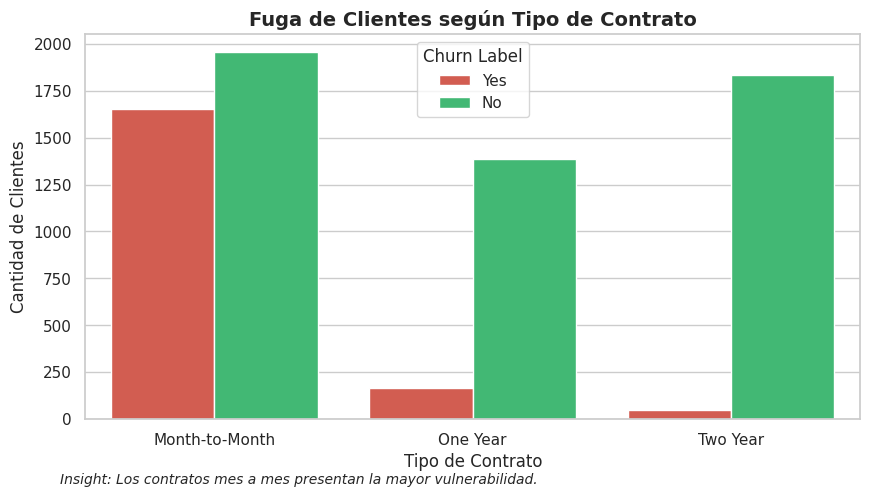

In [18]:
plt.figure(figsize=(10, 5))
# Ordenar barras para facilitar la lectura de tendencias [10]
sns.countplot(data=df_merged, x='Contract', hue='Churn Label', palette=palette_churn,
                    order=['Month-to-Month', 'One Year', 'Two Year'])
plt.title('Fuga de Clientes según Tipo de Contrato', weight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.figtext(0.1, -0.02, "Insight: Los contratos mes a mes presentan la mayor vulnerabilidad.", fontsize=10, style='italic')
plt.show()

Se observa que los clientes con contratos de "Mes a Mes" tienen una tasa de abandono significativamente mayor que aquellos con contratos de 1 o 2 años. Esto se explicar porque al tener contratos mes a mes, los clientes no tienen barreras de salida financieras.

#### 3.2.2 Churn por Tipo de Internet

La variable "Internet Type" indica que tipo de técnología ofrecida al cliente para brindar el servicio de Internet. Conocer la tasa de abandono por tipo de internet, ayuda a validar en cuál tecnología poner foco.



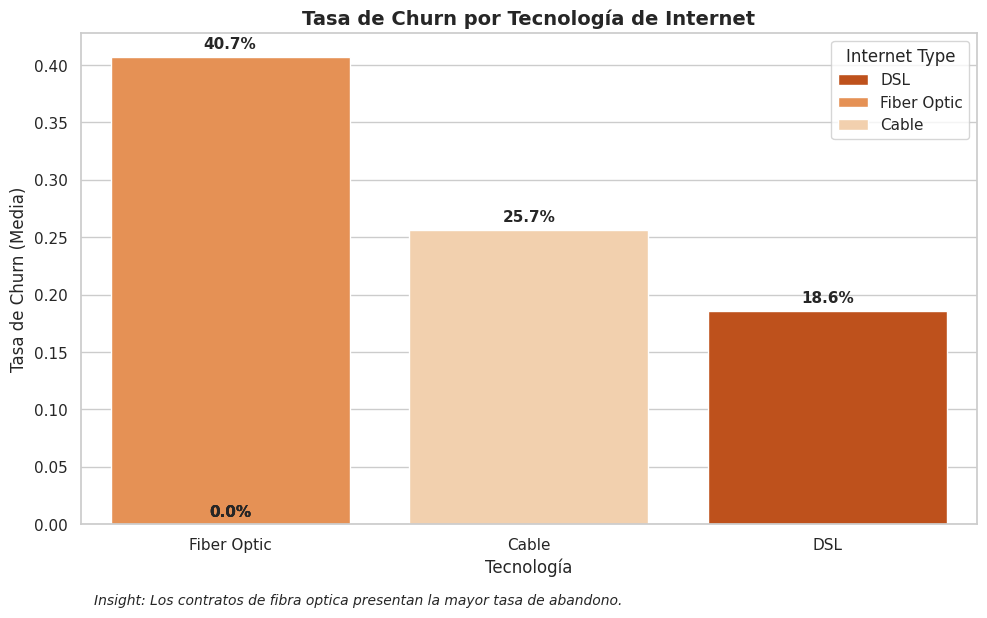

In [19]:
plt.figure()
internet_order = df_merged.groupby('Internet Type')['Churn Value'].mean().sort_values(ascending=False).index
sns.barplot(data=df_merged, x='Internet Type', y='Churn Value', hue='Internet Type', order=internet_order, palette='Oranges_r', errorbar=None)
plt.title('Tasa de Churn por Tecnología de Internet')
plt.ylabel('Tasa de Churn (Media)')
plt.xlabel('Tecnología')
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.figtext(0.1, -0.02, "Insight: Los contratos de fibra optica presentan la mayor tasa de abandono.", fontsize=10, style='italic')
plt.tight_layout()
plt.show()

Contrariamente a lo esperado, se identifica que el abandono es mayor en clientes con tipo de Internet de Fibra Optica (40.7%)comparado con los de Cable (25.7%), y DSL (18.6%). Esto podría explicarse por expectativas no cumplidas en relación a la tecnología como por ejemplo velicidad de acceso o latencia (alto lag).

#### 3.2.3 Distribución de Tenure vs Churn

La variable Tenure en meses mide la fidelidad temporal de los clientes. Conocer la distribución del abandono por meses de permanencia permite observar los rangos criticos en los cuales el abandono es alto.

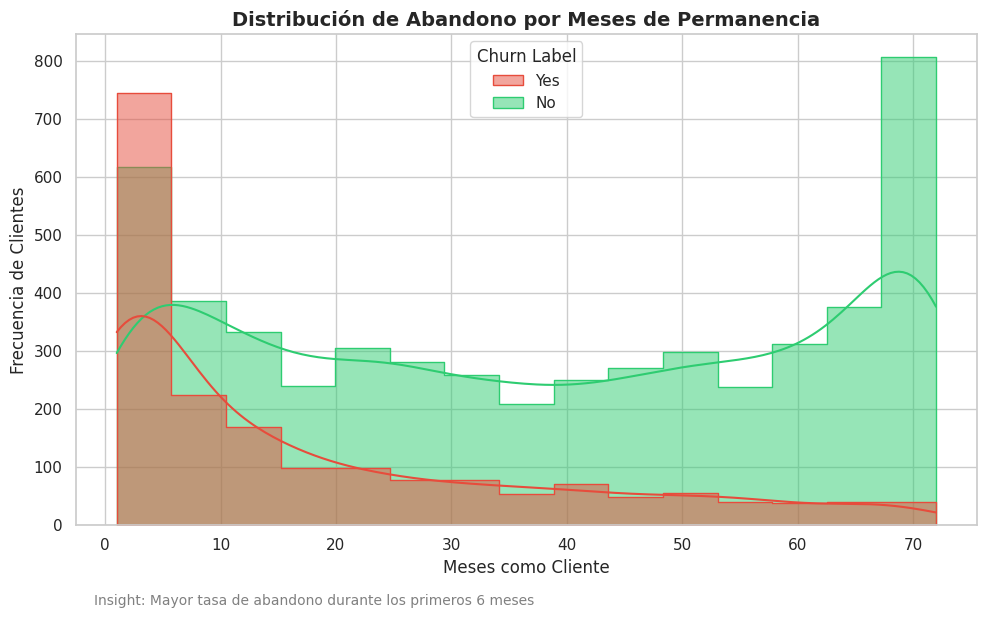

In [25]:
plt.figure()
sns.histplot(data=df_merged, x='Tenure in Months', hue='Churn Label', palette=palette_churn,
             kde=True, element="step", common_norm=False, alpha=0.5)
plt.title('Distribución de Abandono por Meses de Permanencia', weight='bold')
plt.xlabel('Meses como Cliente')
plt.ylabel('Frecuencia de Clientes')
plt.figtext(0.1, -0.02, "Insight: Mayor tasa de abandono durante los primeros 6 meses",
            fontsize=10, color="gray")
plt.tight_layout()
plt.show()

El gráfico de densidad de Abandono por meses de permanencia, revela que el riesgo de fuga es crítico durante los primeros 6 meses de servicio. Esto podría estar relacionado con fallas en el proceso de bienvenida del cliente o expectativas no cumplidas.

#### 3.2.4 Motivos de Churn

Las variables Churn Category y Churn Reason ofrecen la visión cualitativa de los motivos de abandono de clientes.  El gráfico de barras horizontal clasifica estos motivos por frecuencia.

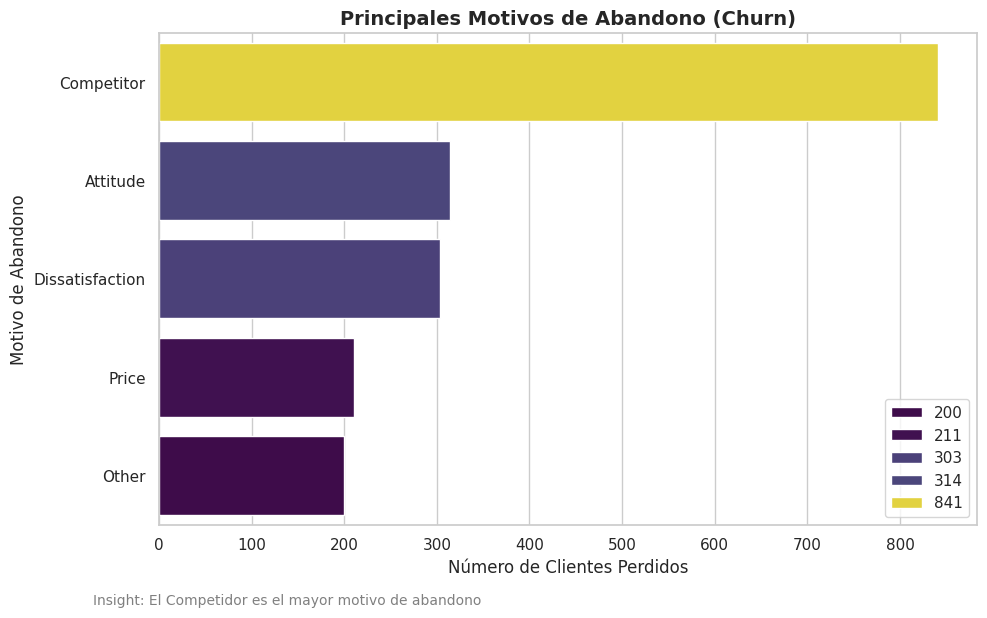

In [24]:
plt.figure()
churn_reasons = df_merged[df_merged['Churn Value'] == 1]['Churn Category'].value_counts()
sns.barplot(x=churn_reasons.values, y=churn_reasons.index, hue=churn_reasons.values, palette='viridis')
plt.title('Principales Motivos de Abandono (Churn)', weight='bold')
plt.xlabel('Número de Clientes Perdidos')
plt.ylabel('Motivo de Abandono')
plt.figtext(0.1, -0.02, "Insight: El Competidor es el mayor motivo de abandono",
            fontsize=10, color="gray")
plt.tight_layout()
plt.show()

La categoría "Competitor" es la que presenta mayor frecuencia. Esto indicaría que el problema no es necesariamente la calidad interna, sino que las ofertas externas (mejores dispositivos, mayor velocidad) están captando al segmento insatisfecho.

#### 3.2.5 Cargos Mensuales vs Churn

La variable Monthly Charge representa el impacto económico directo para el usuario
. Un gráfico de distribución permite comparar en qué valores de cargo se ubican los clientes que abandonan y los que permanecen.

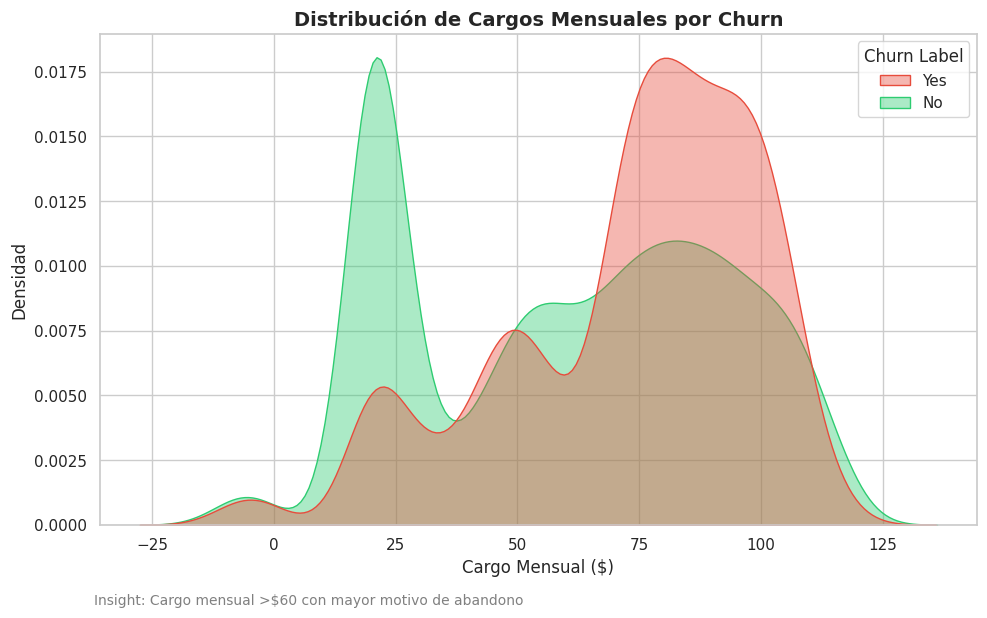

In [22]:
plt.figure()
sns.kdeplot(data=df_merged, x='Monthly Charge', hue='Churn Label', palette=palette_churn,
            fill=True, common_norm=False, alpha=0.4)
plt.title('Distribución de Cargos Mensuales por Churn')
plt.xlabel('Cargo Mensual ($)')
plt.ylabel('Densidad')
plt.figtext(0.1, -0.02, "Insight: Cargo mensual >$60 con mayor motivo de abandono",
            fontsize=10, color="gray")
plt.tight_layout()
plt.tight_layout()
plt.show()

Las gráficas de distribución de cargos mensuales por abandono, muestra que los clientes con cargos mensuales superiores al promedio (>60) presentan una mayor propensión al abandono por insatisfacción de precio

#### 3.2.6 Recomendaciones

Basado en los gráficos anteriores
:


1.   **Conversión de Contratos:**
Dado que el mayor volumen de abandono ocurre en contratos "Mes a Mes", se recomienda ofrecer incentivos (descuentos) para migrar a estos clientes a contratos anuales.

2.   **Plan de Retención Temprana:**
La mayor densidad de abandono ocurre en los primeros 6 meses. Se sugiere implementar un programa de seguimiento proactivo ("Onboarding Success") durante el primer semestre. Asignar asesores comerciales y de servicio que acompañen al cliente y aseguren la calidad de servicio esperada.


3.   **Monitoreo de la Competencia:**
"Competitor" es la categoría con mayor cantidada de abandono. Se sugiere realizar un benchmark de precios y servicios, especialmente para clientes con cargos mensuales altos, quienes son los más propensos a irse por una mejor oferta económica. En base a la comparación, se deben generar promociones y ofertas competitivas para asegurar la permanencia.